In [287]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from qiskit.circuit.library import efficient_su2
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import PauliEvolutionGate
from qiskit import QuantumCircuit

In [288]:
def tfim_hamiltonian(n_qubits, J, h, periodic=False):
    terms = []

    for i in range(n_qubits - 1):
        terms.append(("ZZ", [i, i + 1], -J))

    for i in range(n_qubits):
        terms.append(("X", [i], -h))

    return SparsePauliOp.from_sparse_list(terms, num_qubits=n_qubits).simplify()

H = []
for n in range(0, 5):
    H.append(tfim_hamiltonian(n, J=1.0, h=0.7))

In [289]:
N = 4
hamiltonian = H[N]
A = hamiltonian.to_matrix()

eigenvalues, eigenvectors = np.linalg.eigh(A)

ground_energy = eigenvalues[0]

print(eigenvalues)
print(eigenvectors)

print("Ground-state energy:")
print(ground_energy)

[-3.87298335 -3.59722348 -2.19326222 -1.91750236 -1.27575986 -1.
 -0.67972112 -0.40396126  0.40396126  0.67972112  1.          1.27575986
  1.91750236  2.19326222  3.59722348  3.87298335]
[[-5.66992199e-01+0.j -6.45025680e-01+0.j -4.09420684e-17+0.j
  -3.86993532e-01+0.j -1.84515614e-01+0.j  2.02486143e-18+0.j
  -6.86410698e-17+0.j -1.01554967e-01+0.j -7.74511251e-02+0.j
  -2.14049354e-01+0.j  1.67553055e-16+0.j -1.06880146e-16+0.j
  -8.51895036e-02+0.j -6.38649710e-02+0.j  5.28516961e-17+0.j
   7.20174518e-02+0.j]
 [-2.22420242e-01+0.j -1.80968824e-01+0.j  3.33545031e-01+0.j
   2.27639667e-01+0.j  3.87743517e-01+0.j  5.00000000e-01+0.j
  -3.22672161e-01+0.j  3.27242509e-01+0.j -1.38927774e-01+0.j
   2.39929217e-01+0.j  3.49977999e-18+0.j  1.60494068e-01+0.j
   7.15886077e-02+0.j -9.66396444e-02+0.j -9.41915209e-02+0.j
  -1.31133149e-01+0.j]
 [-1.31133149e-01+0.j -9.41915209e-02+0.j  9.66396444e-02+0.j
   7.15886077e-02+0.j -1.60494068e-01+0.j -1.38777878e-16+0.j
   2.39929217e-01+0.j 

Hardware efficient ansatz

Number of parameters: 24


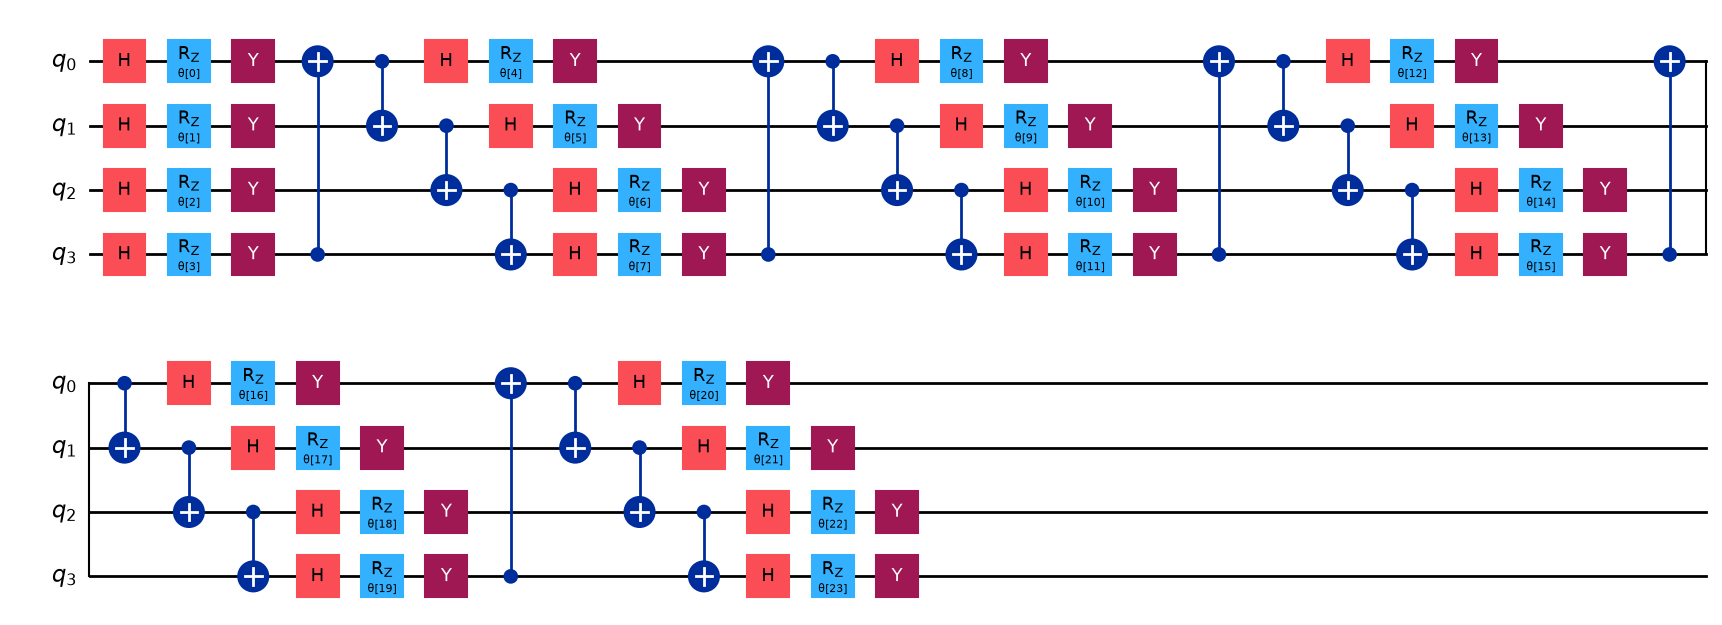

In [290]:
ansatz = efficient_su2(
    hamiltonian.num_qubits,
    su2_gates=["h", "rz", "y"],
    entanglement="circular",
    reps = 5
)

print("Number of parameters:", ansatz.num_parameters)

ansatz.draw("mpl")

Symmetry efficient ansatz

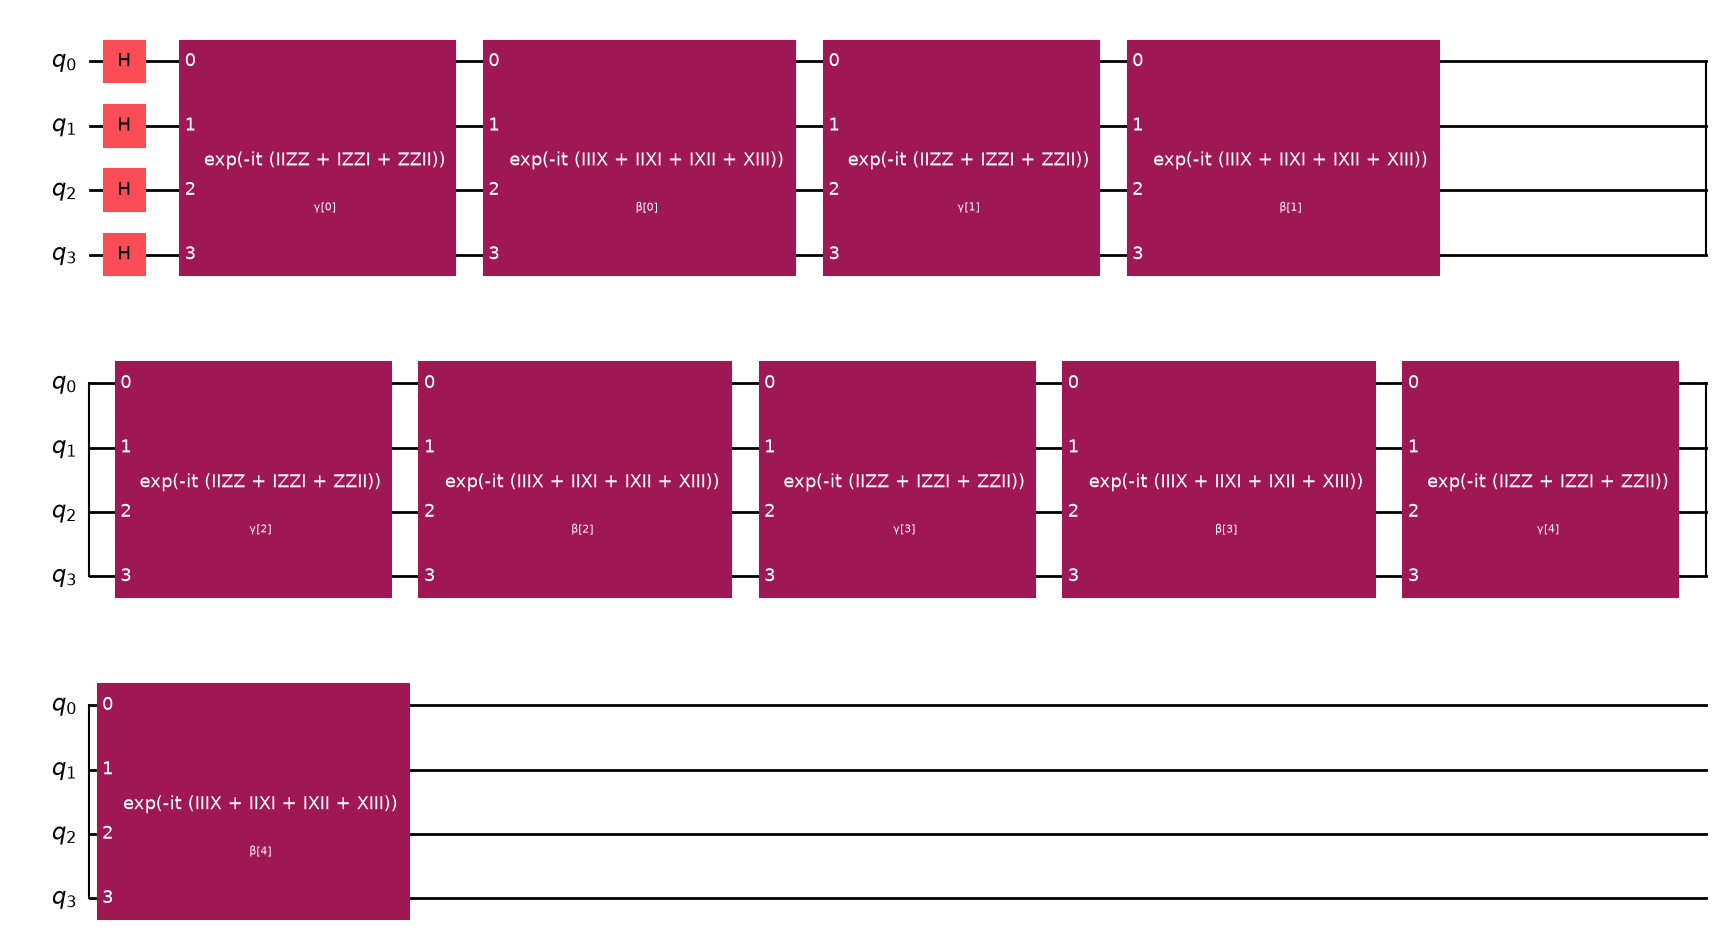

In [291]:
def tfim_symmetry_ansatz(n_qubits: int, reps: int):
    """
    Symmetry-preserving TFIM/QAOA-style ansatz:
        |+>^n
        -> exp(-i gamma_l * sum ZZ)
        -> exp(-i beta_l  * sum X)
    repeated for reps layers.

    Returns:
        qc, gammas, betas
    """
    gammas = ParameterVector("γ", reps)
    betas = ParameterVector("β", reps)

    # Build the two commuting pieces of the TFIM Hamiltonian:
    #   H_ZZ = sum_i Z_i Z_{i+1}
    #   H_X  = sum_i X_i
    zz_terms = SparsePauliOp.from_sparse_list(
        [("ZZ", [i, i + 1], 1.0) for i in range(n_qubits - 1)],
        num_qubits=n_qubits
    )
    x_terms = SparsePauliOp.from_sparse_list(
        [("X", [i], 1.0) for i in range(n_qubits)],
        num_qubits=n_qubits
    )

    ansatz_sym = QuantumCircuit(n_qubits, name="TFIM_ansatz")

    # Start in |+>^n
    for q in range(n_qubits):
        ansatz_sym.h(q)

    # Alternate Ising interaction and transverse-field layers
    for layer in range(reps):
        ansatz_sym.append(PauliEvolutionGate(zz_terms, time=gammas[layer]), range(n_qubits))
        ansatz_sym.append(PauliEvolutionGate(x_terms, time=betas[layer]), range(n_qubits))

    return ansatz_sym, gammas, betas


# Example: build a 4-qubit, 3-rep ansatz
ansatz_sym, gammas, betas = tfim_symmetry_ansatz(N, 5)
ansatz_sym.draw("mpl")

In [292]:
estimator = StatevectorEstimator()

In [293]:
cost_history = {
    "iters": 0,
    "energies": [],
}

In [1]:
def cost_function(params, ansatz_sym, hamiltonian, estimator):

    pub = (ansatz_sym, hamiltonian, [params])

    result = estimator.run([pub]).result()

    energy = result[0].data.evs[0]

    cost_history["iters"] += 1
    cost_history["energies"].append(energy)

    print(
        f"Iteration {cost_history['iters']:2d}"
        f"   Energy = {energy:.8f}"
    )

    return energy

In [295]:
x0 = 2*np.pi*np.random.random(ansatz_sym.num_parameters)
print(x0)

[4.08131313 2.76506665 5.62024639 3.35784031 5.8043534  6.0804454
 2.51610788 3.78174453 3.02695174 4.84367113]


In [296]:
result = minimize(
    cost_function,
    x0,
    args=(ansatz_sym, hamiltonian, estimator),
    method="L-BFGS-B",
    options={"maxiter": 200},
)

Iteration  1   Energy = 0.57471025
Iteration  2   Energy = 0.57471026
Iteration  3   Energy = 0.57471029
Iteration  4   Energy = 0.57471021
Iteration  5   Energy = 0.57471021
Iteration  6   Energy = 0.57471023
Iteration  7   Energy = 0.57471026
Iteration  8   Energy = 0.57471025
Iteration  9   Energy = 0.57471022
Iteration 10   Energy = 0.57471022
Iteration 11   Energy = 0.57471022
Iteration 12   Energy = 0.80143308
Iteration 13   Energy = 0.80143310
Iteration 14   Energy = 0.80143309
Iteration 15   Energy = 0.80143310
Iteration 16   Energy = 0.80143310
Iteration 17   Energy = 0.80143307
Iteration 18   Energy = 0.80143310
Iteration 19   Energy = 0.80143302
Iteration 20   Energy = 0.80143312
Iteration 21   Energy = 0.80143312
Iteration 22   Energy = 0.80143315
Iteration 23   Energy = -3.46710608
Iteration 24   Energy = -3.46710608
Iteration 25   Energy = -3.46710606
Iteration 26   Energy = -3.46710609
Iteration 27   Energy = -3.46710609
Iteration 28   Energy = -3.46710612
Iteration 29  

In [297]:
print()

print("VQE energy:")
print(result.fun)

print()

print("Exact energy:")
print(ground_energy)


VQE energy:
-3.8729833461013525

Exact energy:
-3.872983346207417


In [298]:
plt.rcParams.update({
    "figure.figsize": (11, 5.5),
    "figure.facecolor": "#0b1020",
    "axes.facecolor": "#0b1020",
    "axes.edgecolor": "#cbd5e1",
    "axes.labelcolor": "#e2e8f0",
    "xtick.color": "#cbd5e1",
    "ytick.color": "#cbd5e1",
    "text.color": "#e2e8f0",
    "axes.titleweight": "bold",
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 3.0,
    "grid.color": "#334155",
    "grid.alpha": 0.35,
    "axes.grid": True,
    "legend.frameon": False,
    "font.family": "DejaVu Sans",
})

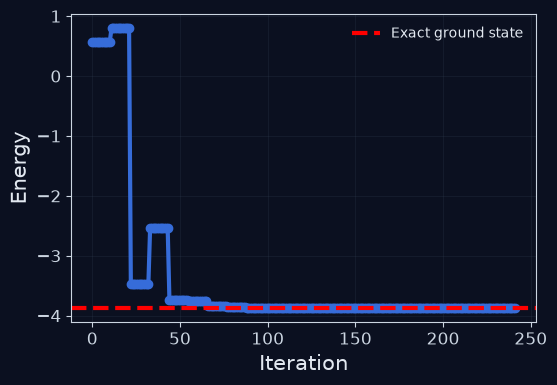

In [299]:
plt.figure(figsize=(6,4))

plt.plot(cost_history["energies"], marker="o")

plt.axhline(
    ground_energy,
    color="red",
    linestyle="--",
    label="Exact ground state"
)

plt.xlabel("Iteration")
plt.ylabel("Energy")

plt.legend()

plt.show()